In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


df=pd.read_csv("daibb.csv")

In [2]:
print(df.head())

   Feature1  Feature2  Outcome
0  2.882026  1.663770        0
1  2.200079  1.820223        0
2  2.489369  1.593427        0
3  3.120447  1.136859        0
4  2.933779  2.088713        0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  120 non-null    float64
 1   Feature2  120 non-null    float64
 2   Outcome   120 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.9 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Feature1,120.0,5.022819,3.038153,0.723505,2.053943,5.181246,7.976594,9.191572
Feature2,120.0,5.024861,2.984773,1.136859,2.082658,4.930055,7.979243,9.129654
Outcome,120.0,0.500000,0.502096,0.000000,0.000000,0.500000,1.000000,1.000000


In [5]:
cat_col=[col for col in df.columns 
         if df[col].dtype=='object']
print("Categorical columns:",cat_col)


Categorical columns: []


In [6]:
df[cat_col].nunique().T

Series([], dtype: float64)

In [7]:
#Check Duplicates

print(df.duplicated().sum())
df.drop_duplicates(inplace=True)


0


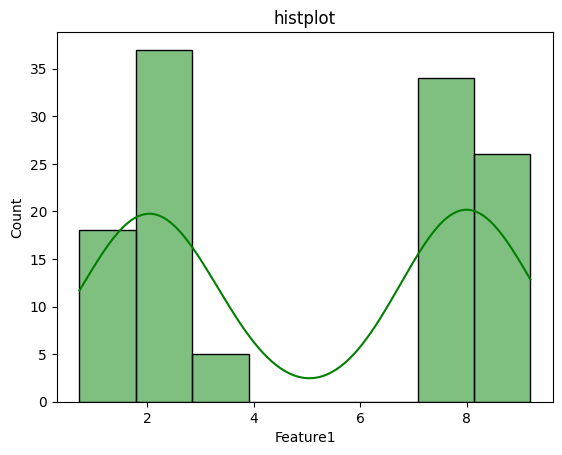

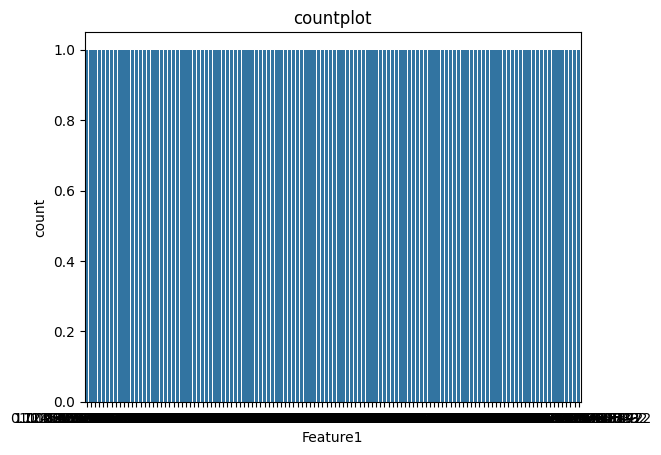

In [9]:
sns.histplot(df['Feature1'], kde=True,color="green")
plt.title("histplot")
plt.show()

#Categorical Count
sns.countplot(x='Feature1', data=df)
plt.title("countplot")
plt.show()

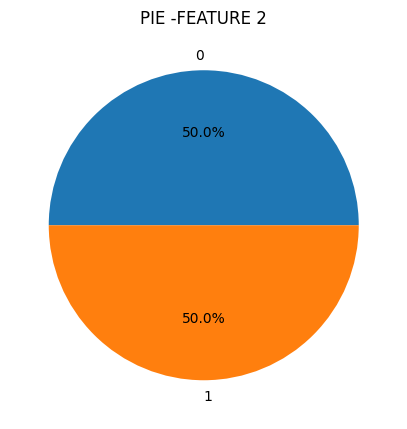

In [13]:
plt.figure(figsize=(5,6))
data=df['Outcome'].value_counts()
plt.title("PIE -FEATURE 2")
plt.pie(data.values,
        labels=data.index,
        autopct='%1.1f%%')
plt.show()

C:\Users\gowth\AppData\Local\Temp\ipykernel_15908\2890944124.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature1',y='Feature2',data=df,color='green',palette='coolwarm')


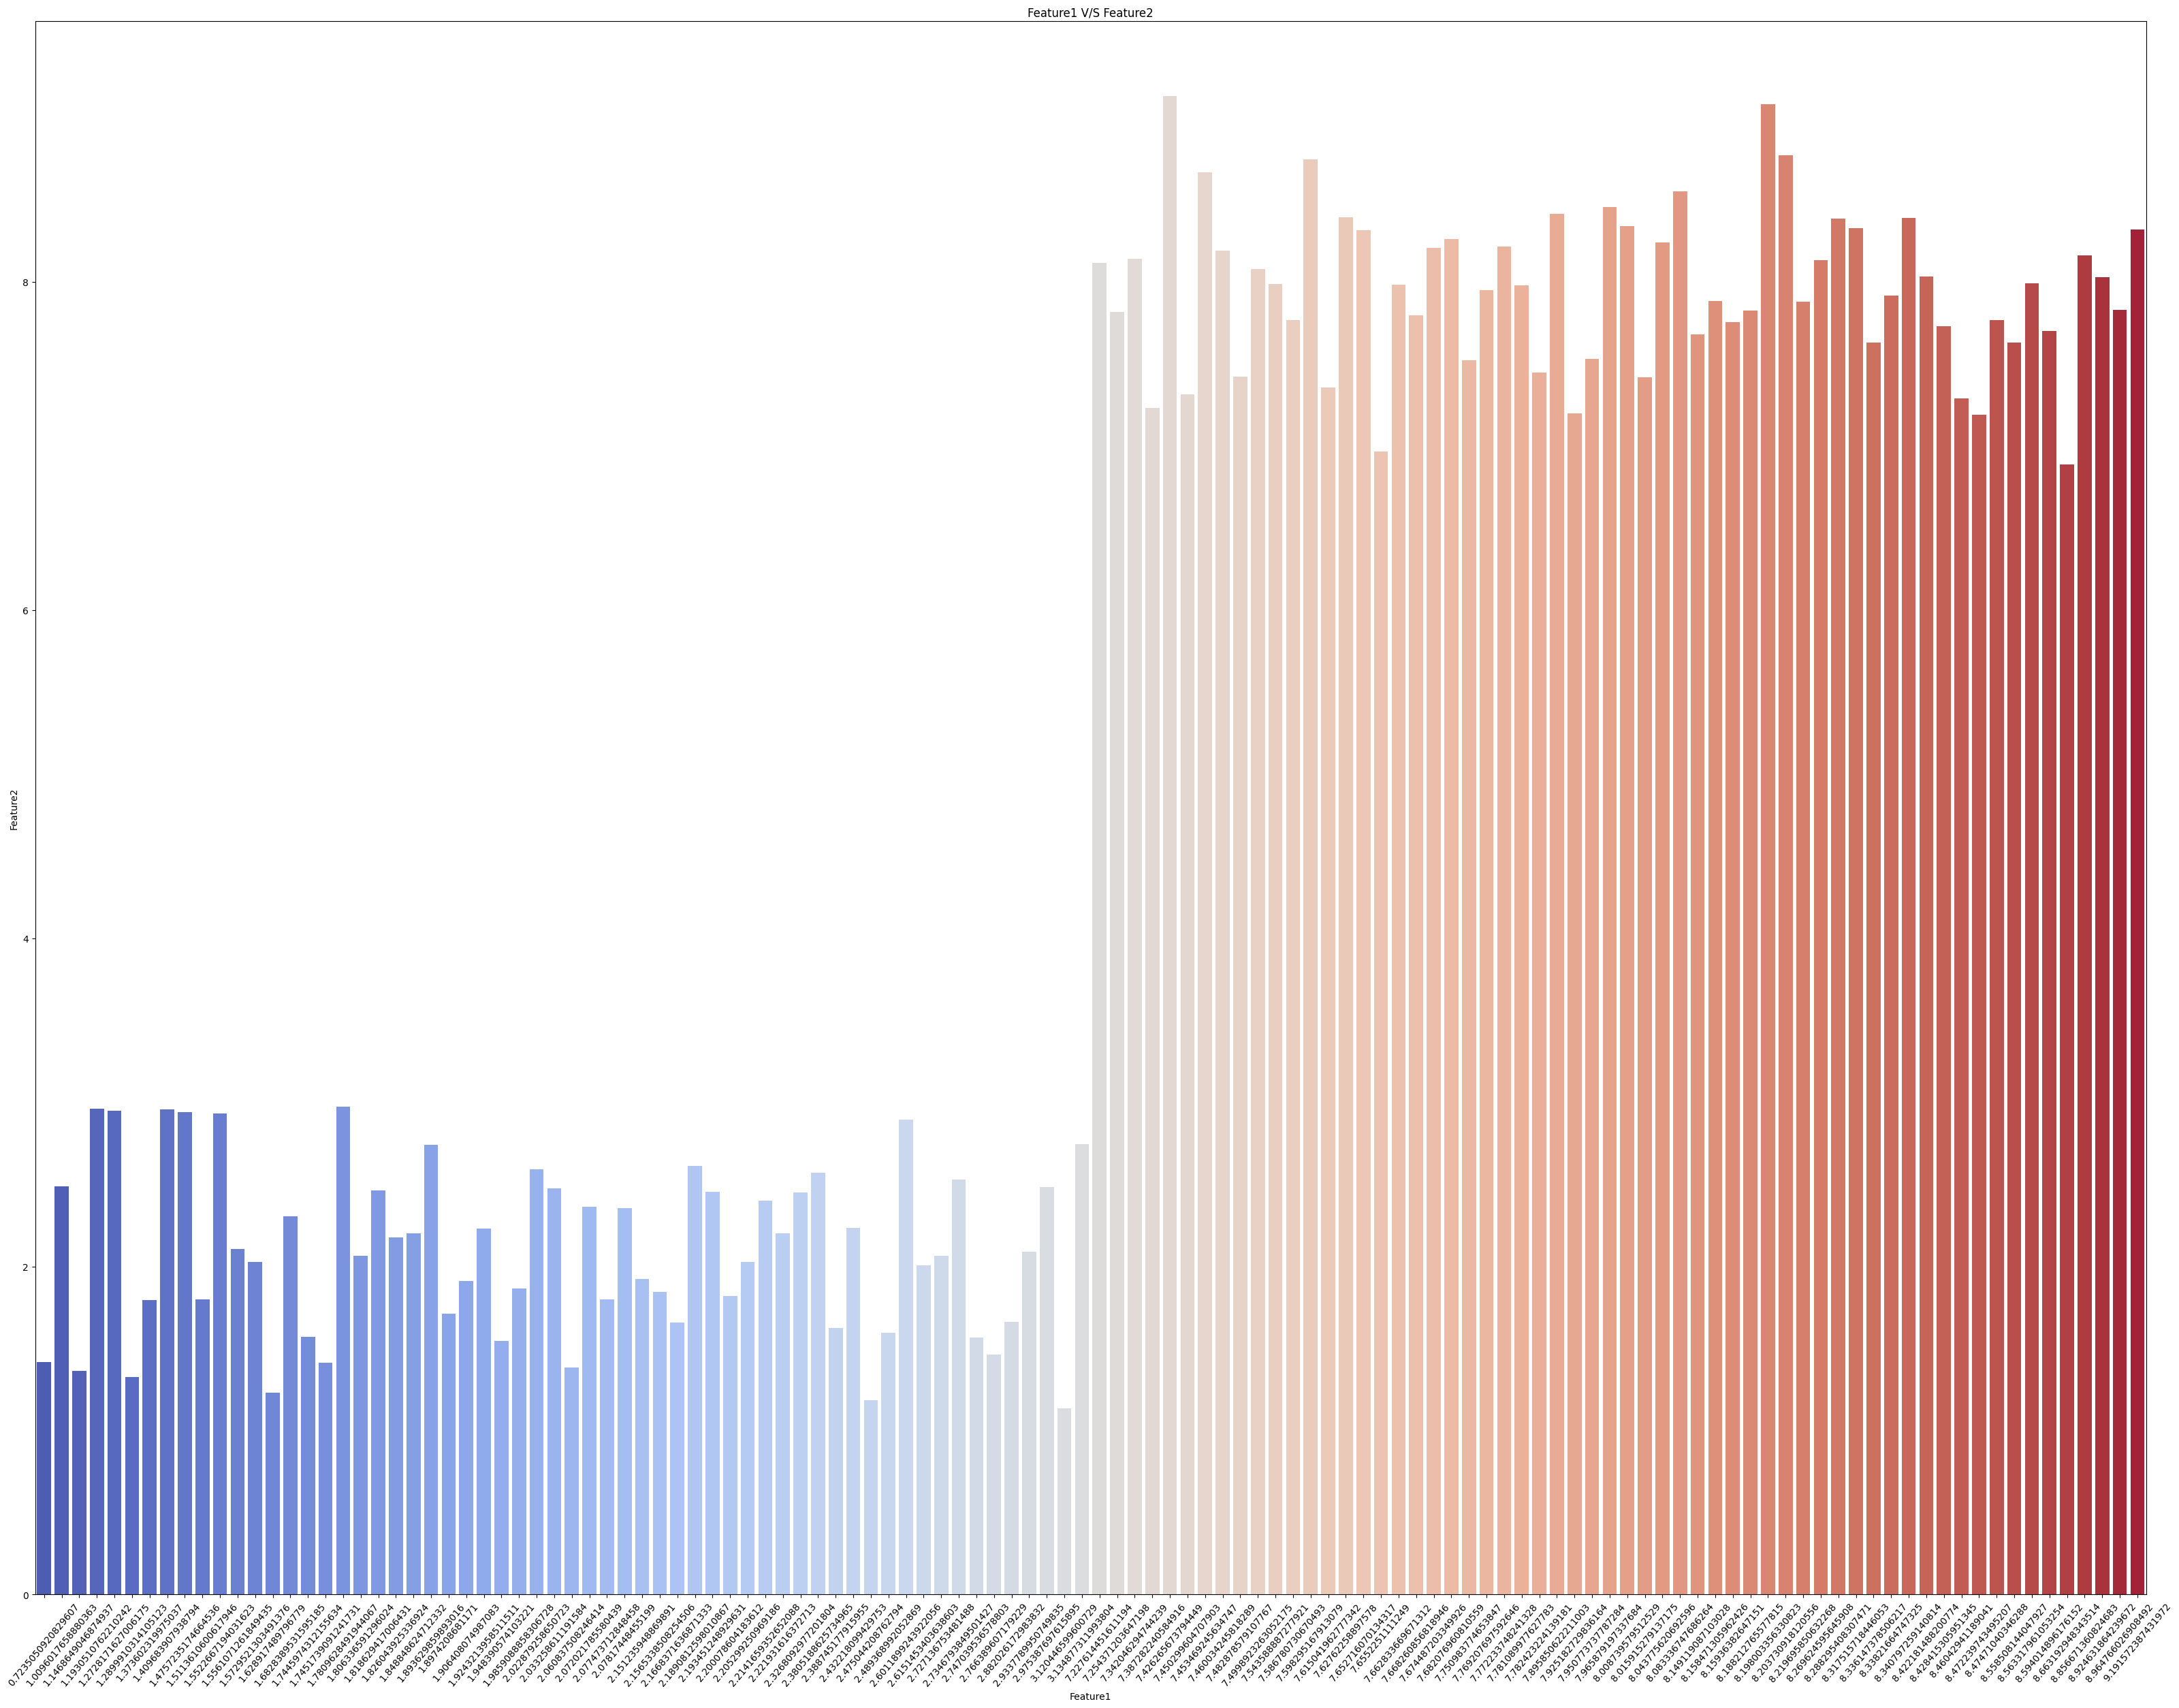

In [17]:
#Bivariate Analysis // Categorical v/s Numerical - barplot....1

plt.figure(figsize=(40,30))
sns.barplot(x='Feature1',y='Feature2',data=df,color='green',palette='coolwarm')
plt.title('Feature1 V/S Feature2')
plt.xticks(rotation=50)
plt.show()

C:\Users\gowth\AppData\Local\Temp\ipykernel_15908\706378009.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Feature1',y='Outcome',data=df,color='aqua',palette='coolwarm')


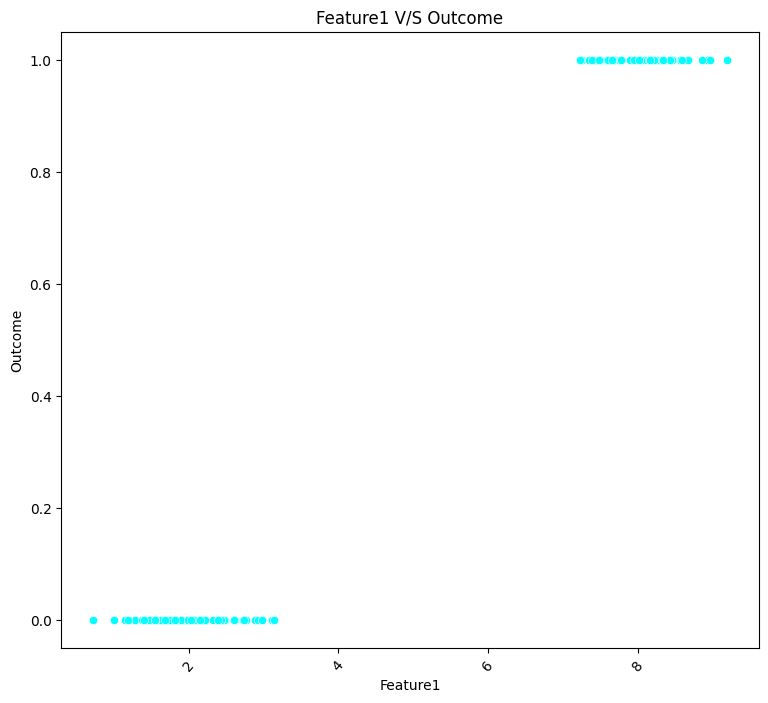

In [19]:
#Bivariate Analysis // Numerical v/s Numerical - scatterplot....1

plt.figure(figsize=(9,8))
sns.scatterplot(x='Feature1',y='Outcome',data=df,color='aqua',palette='coolwarm')
plt.title('Feature1 V/S Outcome')
plt.xticks(rotation=50)
plt.show()

C:\Users\gowth\AppData\Local\Temp\ipykernel_15908\1059317369.py:5: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Orange'` for the same effect.

  sns.countplot(hue='Feature2',y='Outcome',data=df,color='Orange')


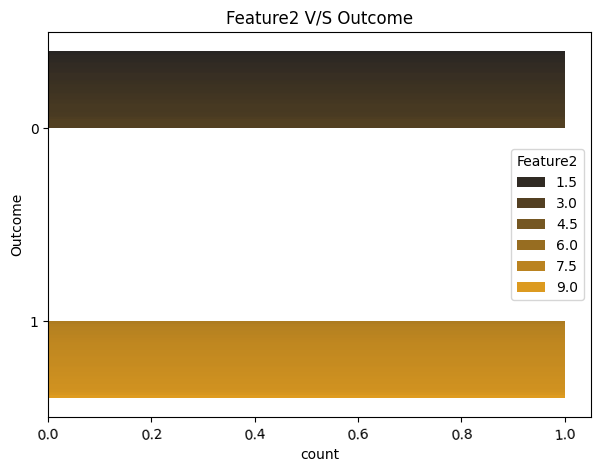

In [22]:
#Bivariate Analysis // Categorical v/s Categorical - Countplot....1


plt.figure(figsize=(7,5))
sns.countplot(hue='Feature2',y='Outcome',data=df,color='Orange')
plt.title('Feature2 V/S Outcome')
plt.xticks(rotation=4)
plt.show()


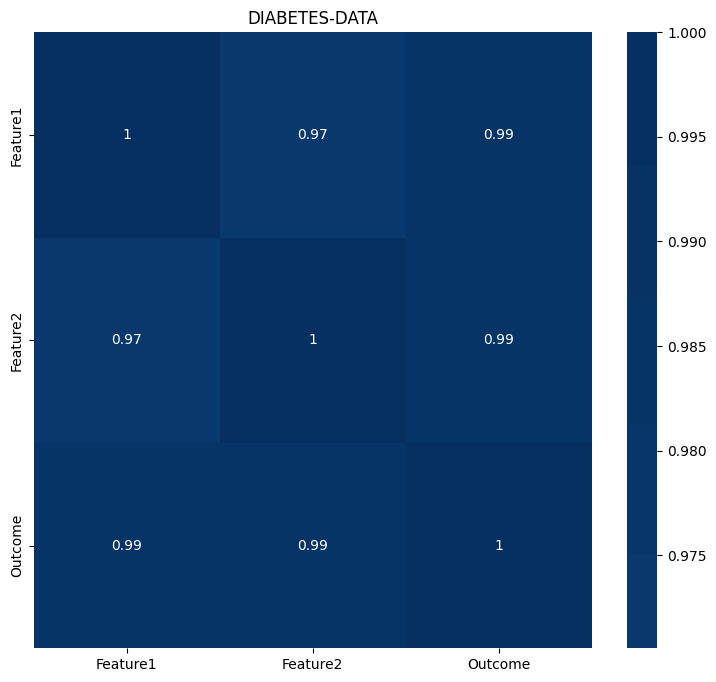

In [29]:
# Multi variate Analysis // HEAT MAP


#Correlation Heatmap


plt.figure(figsize=(9,8))
plt.title("DIABETES-DATA")
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='RdBu',center=0.2) #cmap=viridis,plasma,inferno,magma,coolwarm,RdBu...etc
plt.show()



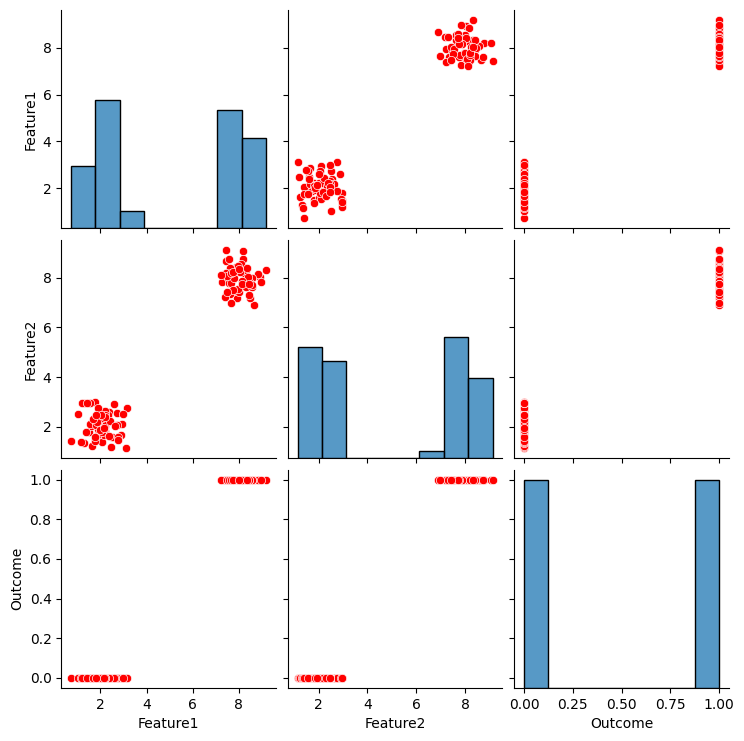

In [32]:
#Pair Plot (Full Relationship View)

sns.pairplot(df[[ 'Feature1','Feature2','Outcome']],plot_kws={'color':'red'})
plt.show()


Feature1    0
Feature2    0
Outcome     0
dtype: int64
MAE : 0.052959901543395714
MSE : 0.0036533658649111358
RMSE: 0.060443079545231114
R2 Score: 0.9852843444881901


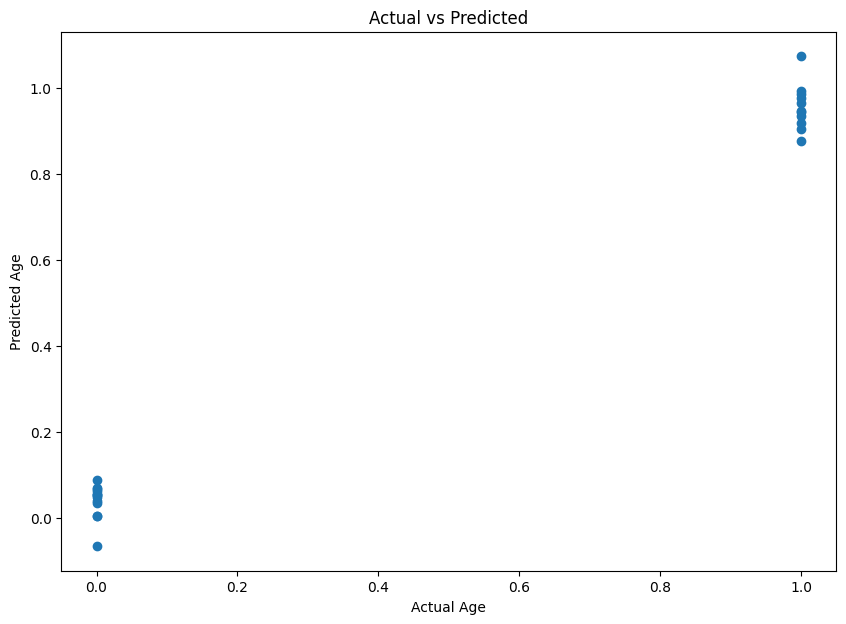

In [4]:
# Model Building (Linear Regression)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load Dataset
df = pd.read_csv("daibb.csv")


# Check missing values
print(df.isnull().sum())

# Convert categorical data (if any)
df = pd.get_dummies(df, drop_first=True)


# Define Features (X) and Target (y)
X = df.drop("Outcome",axis=1)
y = df["Outcome"]


# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Model Building
model = LinearRegression()
model.fit(X_train, y_train)


# Make Predictions
y_pred = model.predict(X_test)


# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


# Print Results
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

plt.figure(figsize=(10,7))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted")
plt.show()

Accuracy: 1.0

Confusion Matrix:
 [[13  0]
 [ 0 11]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        11

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



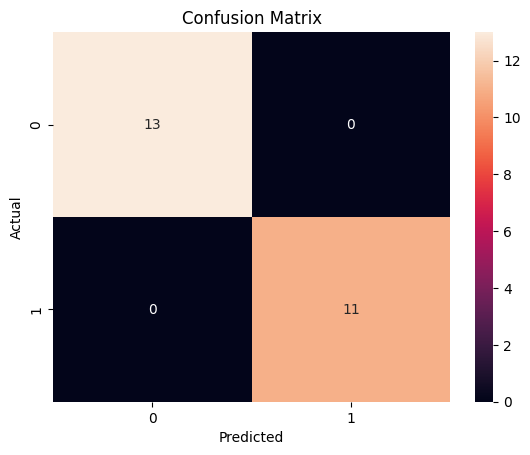

In [6]:
# Logistic Regression Model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
df = pd.read_csv("daibb.csv")

# Define Features (X) and Target (y)
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)


print("Accuracy:",accuracy)
print("\nConfusion Matrix:\n",cm)
print("\nClassification Report:\n", report)


# Confusion Matrix Plot
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [7]:
print(classification_report(y_test, y_pred))

report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        11

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24

              precision  recall  f1-score  support
0                   1.0     1.0       1.0     13.0
1                   1.0     1.0       1.0     11.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     24.0
weighted avg        1.0     1.0       1.0     24.0


In [8]:
#Model Evaluation // Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

#Classification Report (Table Format)
report = pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
print("\nClassification Report Table\n")
print(report)

Accuracy: 1.0

Classification Report Table

              precision  recall  f1-score  support
0                   1.0     1.0       1.0     13.0
1                   1.0     1.0       1.0     11.0
accuracy            1.0     1.0       1.0      1.0
macro avg           1.0     1.0       1.0     24.0
weighted avg        1.0     1.0       1.0     24.0
